## <span style="color:blue"> Lezione 8 </span>



In [16]:

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as colors

import numpy as np

parent_folder="l_08_all_es/"

Del sistema monodimensionale retto dall'hamiltoniana $H(x,p)=\frac{p^2}{2m} + V(x)$ con $V(x)=x^4 - \frac{5}{2} x^2$ si vuole trovare il ground state, ossia la funzione d'onda $\phi$ che minimizza $$\langle H \rangle _{\phi}= \int \mathrm{d} x \phi^*(x) H(x,p) \phi(x)$$. 

Data la funzione di prova $ \psi_T^{\sigma,\mu}(x) \propto e^{-\frac{(x-\mu)^2}{2\sigma^2}} + e^{-\frac{(x+\mu)^2}{2\sigma^2}} $ 
si cercano quindi i parametri $\mu$ e $\sigma$ che minimizzano $\langle H \rangle _{\sigma,\mu} := \langle H \rangle _{\psi_{\sigma,\mu}}$. 

Ciò viene fatto tramite un algoritmo di simulated annealing, costituito dall'algorimo di Metropolis, per cui una proposta di mossa consiste nel cambiare i parametri $\mu$ e $\sigma$ con accettanza $$ \exp \left(-\beta \left(\langle H \rangle_{\sigma_{\text{new}},\mu_{\text{new}}} \rangle - \langle H \rangle_{\sigma,\mu} \rangle \right) \right) $$ 
con $\beta=1/T$, accompagnato da un "raffreddamento": $T_j=\alpha T_{j-1}$, $\alpha \in (0,1)$.  

L'integrale viene riscritto nel seguente modo: 
$$ \langle H \rangle_{\psi} \rangle = \int dx |\psi(x)|^2 \frac{ H(x,p) \psi(x) }{\psi(x)} $$

e viene calcolato mediando con data blocking la quantità $\frac{ H(x,p) \psi(x) }{\psi(x)}$ per $x$ campionate da $|\psi(x)|^2$ tramite algoritmo di Metropolis.


Nella cella sottostante, invece, è stato copiato il codice che effettua il calcolo "teorico" per confronto coi risultati delle simulazioni. 

In [17]:
def Vpot(x):
    return (x**2 - 2.5)*x**2
    #return 0.5*x**2

hbar = 1
m = 1
a = 10
N = 1000 # number of iterations

# Step sizes
x = np.linspace(-a/2, a/2, N)
dx = x[1] - x[0] # the step size
V = Vpot(x)

# The central differences method: f" = (f_1 - 2*f_0 + f_-1)/dx^2

CDiff = np.diag(np.ones(N-1),-1)-2*np.diag(np.ones(N),0)+np.diag(np.ones(N-1),1)
# np.diag(np.array,k) construct a "diagonal" matrix using the np.array
# The default is k=0. Use k>0 for diagonals above the main diagonal, 
# and k<0 for diagonals below the main diagonal

# Hamiltonian matrix
H = (-(hbar**2)*CDiff)/(2*m*dx**2) + np.diag(V)

# Compute eigenvectors and their eigenvalues
E,psi = np.linalg.eigh(H)

# Take the transpose & normalize
psi = np.transpose(psi)
psi = psi/np.sqrt(dx)

print("Ground state energy: ", E[0])
print("1st excited state energy: ", E[1])
print("2nd excited state energy: ", E[2])

# Plot a few things
#plt.figure(figsize=(8,5))
#scale = 0.3
#plt.plot(x, scale*V, color="Black", label="Potential") # plot the potential
#plt.plot(x,(psi[0])**2)
#plt.plot(x,(psi[1])**2)
#plt.plot(x,(psi[2])**2)
#plt.title("Potential & Probabilities")
#plt.xlabel("x")
#plt.grid(True)
#plt.xlim((-3,3))
#plt.ylim((-0.6,0.6))
#plt.show()


Ground state energy:  -0.4604658796927152
1st excited state energy:  0.0974247133176099
2nd excited state energy:  1.9717331343930193


### <span style="color:DodgerBlue"> Esercizio 8.2 </span>




Come regola di selezione di una nuova quantità per una mossa Metropolis si è scelta la seguente: $q_{\mathrm{new}}= q_{\mathrm{old}} + u \delta$, con $u$ estratto 
uniformemente tra $0$ e $1$ e $\delta$ un parametro. Questa scelta è stata utilizzata sia per $x$ nel Metropolis "interno", sia per $\sigma$ e $\mu$ nel Metropolis "esterno". 

La simulazione è stata effettuata con i seguenti parametri: 

1. Delta Metropolis interno $\delta_{\mathrm{in}}=0.9$
2. Numero blocchi $\N_{\mathrm{blocks}}=100$ e step per blocco $\N_{\mathrm{steps}}=1000$
3. Temperatura di partenza $T_0=2.0$. $\beta_0=0.5$
4. Cooling factor $\alpha=0.75$
5. Numero di valori di $\beta$ considerati $B=40$: $\beta_i=  \beta_0 /\alpha^i$ 
Il delta del Metropolis esterno e il numero di step Metropolis per $\beta$ fissato, invece, sono stati variati opportunatamente per cercare di mantenere l'accettanza del Metropolis esterno a $0.5$. Si nota che, nonostante questi accorgimenti, per valori di $\beta$ alti l'accettanza risulta nulla, o quasi. 


Nella cella sottostante vengono caricati i valori di $\beta$ utilizzati, e i valori di $\sigma,\mu$  e  $\langle H \rangle _{\sigma,\mu} $ col suo errore per ogni step Metropolis. 

In [18]:
beta=np.loadtxt(f"{parent_folder}/Results.csv",usecols=1,skiprows=1)
T=1/beta

B=len(beta)


sigma=[]
mu=[]
avg_H=[]
avg_H_err=[]

for i in range(B):

    filename=f"{parent_folder}/OUTPUT/" + str(i)+".csv"

    data=np.loadtxt(filename,delimiter=",",usecols=(0,1,2,3),skiprows=1)
    data = np.atleast_2d(data)
    sigma.append(data[:,0])
    mu.append(data[:,1])
    avg_H.append(data[:,2])
    avg_H_err.append(data[:,3])








In [19]:

#numero di step metropolis per ogni beta
R=np.array([len(s) for s in sigma]) 
Max_step=R.sum()
steps=np.arange(1,Max_step+1)
split_steps = np.split(steps, np.cumsum(R)[:-1]) 

all_sigma=np.concat([s for s in sigma])
all_mu=np.concat([m for m in mu])

#color map, per segnare l'andamento della temperatura
cmap = plt.get_cmap('plasma_r')
norm = colors.Normalize(vmin=0, vmax=B-1)

La cella sottostante grafica $\langle H \rangle _{\sigma,\mu} $ in funzione del numero di step Metropolis. La scala di colore indica l'abbassamento della temperatura.

Text(0.5, 0.98, 'Evoluzione di parametri $\\langle H \\rangle_{\\sigma,\\mu}$, al variare del numero di steps e della temperatura $T$')

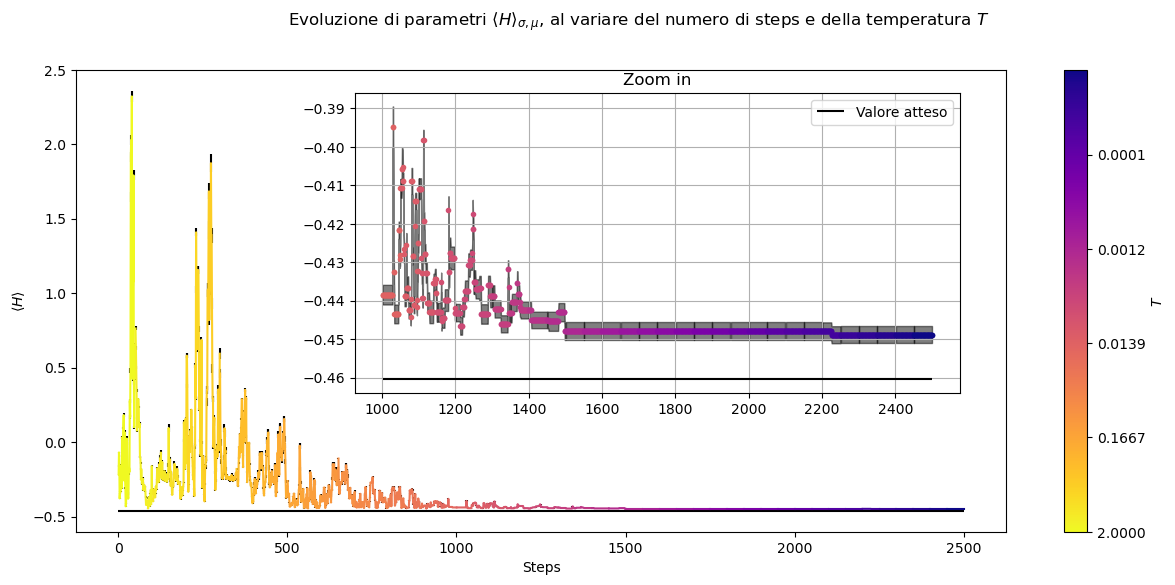

In [25]:
fig,ax=plt.subplots(1,1,figsize=[15,6])

ax_ins = ax.inset_axes([0.3, 0.3, 0.65, 0.65])
zoom_in_index=20


for i in range(B):
    color = cmap(norm(i))
    ax.errorbar(split_steps[i],avg_H[i],yerr=avg_H_err[i],color=color,ecolor="black")
    if (i>=zoom_in_index):
        ax_ins.plot(split_steps[i],avg_H[i],".",color=color)
        ax_ins.fill_between(split_steps[i],avg_H[i]-avg_H_err[i], avg_H[i]+avg_H_err[i],alpha=0.5, color="black")



ax_ins.set_title("Zoom in")

ax.hlines(E[0],0,steps[-1],color="black",label="Valore atteso")
ax_ins.hlines(E[0],split_steps[zoom_in_index][0],steps[-1],color="black",label="Valore atteso")
ax_ins.legend()

#ax.grid()
ax_ins.grid()
ax.set_xlabel("Steps")
ax.set_ylabel(r"$\langle H \rangle $")


sm = cm.ScalarMappable(cmap=cmap, norm=norm)
cbar=fig.colorbar(sm, ax=ax, label=r'$T$')
ticks=cbar.get_ticks()

selected_T = T[ticks[:-1].astype(int)]
#labels = [f"{val:.3e}" if val < 0.001 else f"{val:.3f}" for val in selected_T]
labels = [ f"{val:.4f}" for val in selected_T]

cbar.set_ticks(ticks=ticks[:-1],labels=labels)

fig.suptitle(r"Evoluzione di parametri $\langle H \rangle_{\sigma,\mu}$, al variare del numero di steps e della temperatura $T$")




Text(0.5, 0.98, 'Evoluzione dei parametri $\\sigma$ e $\\mu$, al variare del numero di steps e della temperatura $T$')

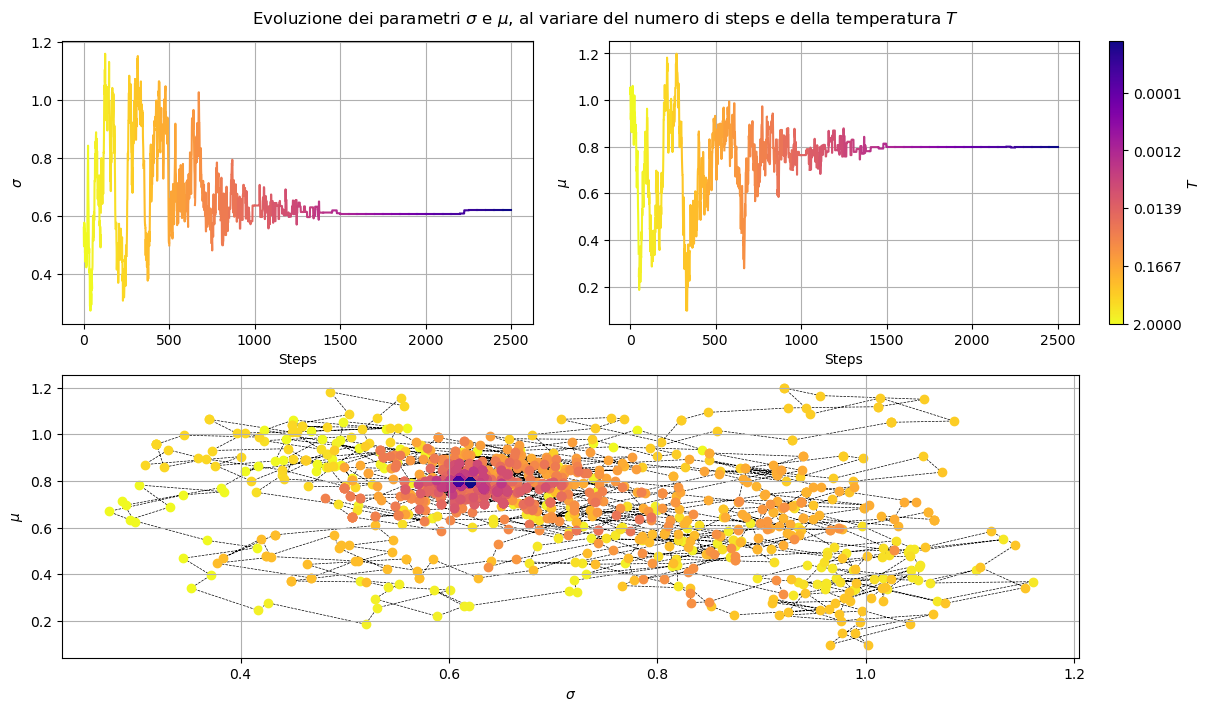

In [23]:


fig, axs = plt.subplot_mosaic([['top left', 'top right'],['bottom', 'bottom']], figsize=(12, 7), constrained_layout=True)


axs["bottom"].plot(all_sigma,all_mu,color="black",ls="--",lw=0.5,zorder=-1)


for i in range(B):
    color = cmap(norm(i))
    axs["top left"].plot(split_steps[i],sigma[i],color=color)
    axs["top right"].plot(split_steps[i],mu[i],color=color)
    axs["bottom"].scatter(sigma[i],mu[i],color=color,zorder=1)



axs["top left"].grid()
axs["top right"].grid()
axs["bottom"].grid()


axs["top left"].set_xlabel(r"Steps")
axs["top right"].set_xlabel(r"Steps")

axs["top left"].set_ylabel(r"$\sigma $")
axs["top right"].set_ylabel(r"$\mu $")

axs["bottom"].set_xlabel(r"$\sigma $")
axs["bottom"].set_ylabel(r"$\mu $")


sm = cm.ScalarMappable(cmap=cmap, norm=norm)
cbar=fig.colorbar(sm, ax=axs["top right"], label=r'$T$')
ticks=cbar.get_ticks()

cbar.set_ticks(ticks=ticks[:-1],labels=labels)

fig.suptitle(r"Evoluzione dei parametri $\sigma$ e $\mu$, al variare del numero di steps e della temperatura $T$")



Per i 

Text(0.5, 0.98, 'Dettaglio dei parametri ottimizzati $\\sigma$=0.6198,  $\\mu$=0.7966')

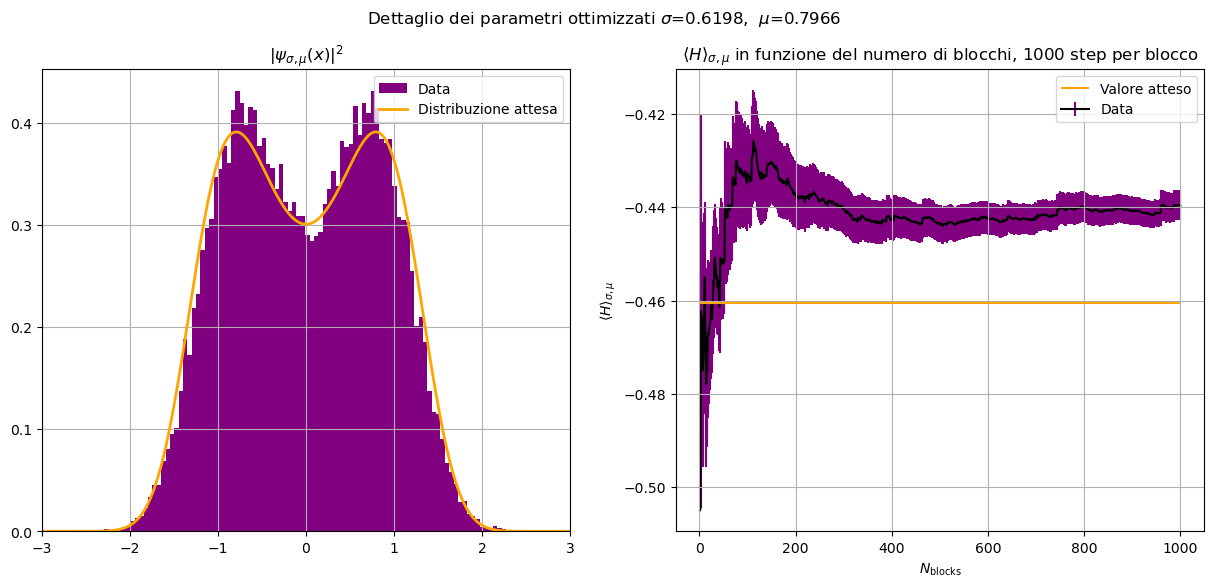

In [35]:


x_dist=np.loadtxt(f"{parent_folder}x_dist.dat")
integral,error=np.loadtxt(f"{parent_folder}integral.dat",usecols=(2,3),unpack=True,skiprows=1)
blocks=np.arange(1,len(integral)+1)

fig,axs=plt.subplots(1,2,figsize=[15,6])


axs[0].hist(x_dist,100,color="purple",density=True,label="Data")
axs[0].plot(x,(psi[0])**2,color="orange",lw=2.0, label="Distribuzione attesa")
axs[0].grid()
axs[0].set_xlim(-3,3)
axs[0].set_title(r"$|\psi_{\sigma,\mu}(x)|^2$")

axs[0].legend()

axs[1].errorbar(blocks,integral,error,color="black",ecolor="purple",label="Data",zorder=-1)
axs[1].hlines(E[0],blocks[0],blocks[-1],color="orange",label="Valore atteso")


axs[1].legend()
axs[1].grid()

axs[1].set_ylabel(r"$\langle H \rangle_{\sigma,\mu}$")

axs[1].set_xlabel(r"$N_{\mathrm{blocks}}$")

axs[1].set_title(r"$\langle H\rangle_{\sigma,\mu} $ in funzione del numero di blocchi, $1000$ step per blocco")


fig.suptitle(rf"Dettaglio dei parametri ottimizzati $\sigma$={sigma[-1][-1]:.4f},  $\mu$={mu[-1][-1]:.4f}")



